## Z-Score Method
A **Z-score**, also known as a standard score, is a statistical measure that tells you how many standard deviations a specific data point is from the mean (average) of its group

$$Z = \frac{x - \mu}{\sigma}$$

![download.png](C%3A/Users/chour/AppData/Local/Temp/download.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
766,7.17,34.0,0
514,7.36,15.0,0
242,5.99,44.0,0
422,7.09,19.0,0
764,6.47,70.0,1


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

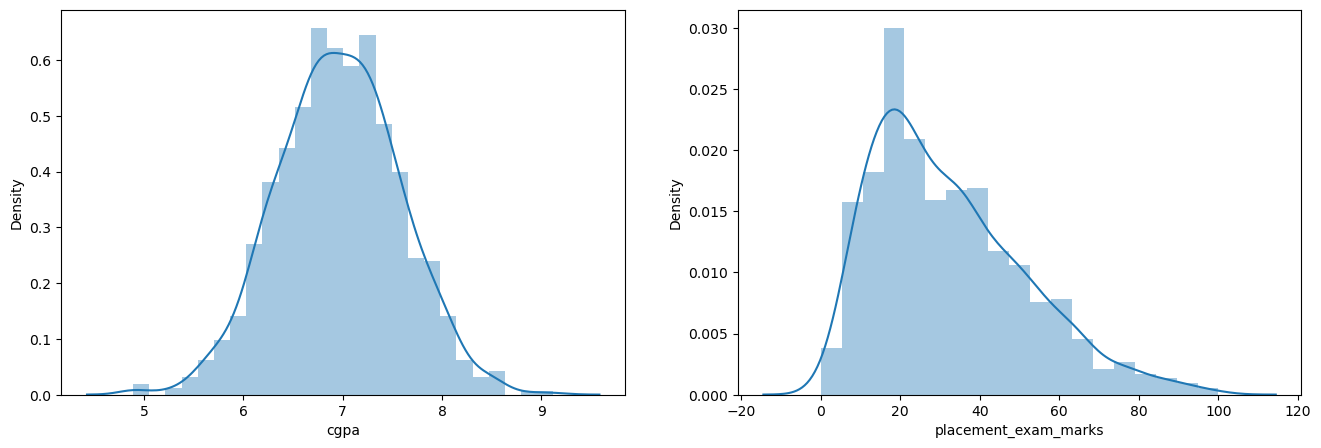

In [3]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['cgpa'])

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])

In [5]:
print("Mean value of Cgpa", df['cgpa'].mean())
print("Std value of Cgpa", df['cgpa'].std())
print("Min value of Cgpa", df['cgpa'].min())
print("Max value of Cgpa", df['cgpa'].max())

Mean value of Cgpa 6.96124
Std value of Cgpa 0.6158978751323894
Min value of Cgpa 4.89
Max value of Cgpa 9.12


In [6]:
#finding the boundaries values

print("Highest allowed", df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed", df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [9]:
# Finding outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

### 1. Approach 1

In [10]:
new_df = df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

new_df.head()

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### 2. Approach 2

In [11]:
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [12]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [14]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [17]:
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

new_df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


## Capping

In [18]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [19]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
        )
)

In [20]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

In [21]:
df.sample(5)

,cgpa,placement_exam_marks,placed,cgpa_zscore
245,6.780000,62.0,0,-0.294270
308,7.200000,47.0,1,0.387662
313,6.510000,18.0,1,-0.732654
995,8.808934,44.0,1,3.099150
12,6.580000,16.0,1,-0.618999
